In [1]:
import pandas as pd

df = pd.read_csv("immo_data.csv")

print(df.shape)      # how many rows and columns
print(df.columns)    # names of all columns
df.head()            # first 5 rows

(268850, 49)
Index(['regio1', 'serviceCharge', 'heatingType', 'telekomTvOffer',
       'telekomHybridUploadSpeed', 'newlyConst', 'balcony', 'picturecount',
       'pricetrend', 'telekomUploadSpeed', 'totalRent', 'yearConstructed',
       'scoutId', 'noParkSpaces', 'firingTypes', 'hasKitchen', 'geo_bln',
       'cellar', 'yearConstructedRange', 'baseRent', 'houseNumber',
       'livingSpace', 'geo_krs', 'condition', 'interiorQual', 'petsAllowed',
       'street', 'streetPlain', 'lift', 'baseRentRange', 'typeOfFlat',
       'geo_plz', 'noRooms', 'thermalChar', 'floor', 'numberOfFloors',
       'noRoomsRange', 'garden', 'livingSpaceRange', 'regio2', 'regio3',
       'description', 'facilities', 'heatingCosts', 'energyEfficiencyClass',
       'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice', 'date'],
      dtype='str')


,regio1,serviceCharge,heatingType,telekomTvOffer,telekomHybridUploadSpeed,newlyConst,balcony,picturecount,pricetrend,telekomUploadSpeed,...,regio2,regio3,description,facilities,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice,date
0,Nordrhein_Westfalen,245.00,central_heating,ONE_YEAR_FREE,NaN,False,False,6,4.62,10.0,...,Dortmund,Schüren,Die ebenerdig zu erreichende Erdgeschosswohnun...,Die Wohnung ist mit Laminat ausgelegt. Das Bad...,NaN,NaN,NaN,NaN,NaN,May19
1,Rheinland_Pfalz,134.00,self_contained_central_heating,ONE_YEAR_FREE,NaN,False,True,8,3.47,10.0,...,Rhein_Pfalz_Kreis,Böhl_Iggelheim,Alles neu macht der Mai – so kann es auch für ...,NaN,NaN,NaN,2019.0,NaN,NaN,May19
2,Sachsen,255.00,floor_heating,ONE_YEAR_FREE,10.0,True,True,8,2.72,2.4,...,Dresden,Äußere_Neustadt_Antonstadt,Der Neubau entsteht im Herzen der Dresdner Neu...,"* 9 m² Balkon\n* Bad mit bodengleicher Dusche,...",NaN,NaN,NaN,NaN,NaN,Oct19
3,Sachsen,58.15,district_heating,ONE_YEAR_FREE,NaN,False,True,9,1.53,40.0,...,Mittelsachsen_Kreis,Freiberg,Abseits von Lärm und Abgasen in Ihre neue Wohn...,NaN,87.23,NaN,NaN,NaN,NaN,May19
4,Bremen,138.00,self_contained_central_heating,NaN,NaN,False,True,19,2.46,NaN,...,Bremen,Neu_Schwachhausen,Es handelt sich hier um ein saniertes Mehrfami...,Diese Wohnung wurde neu saniert und ist wie fo...,NaN,NaN,NaN,NaN,NaN,Feb20


In [7]:
df[["baseRent", "totalRent", "livingSpace", "noRooms", "yearConstructed"]].describe()

,baseRent,totalRent,livingSpace,noRooms,yearConstructed
count,2.688500e+05,2.283330e+05,268850.000000,268850.000000,211805.000000
mean,6.941294e+02,9.013315e+02,74.355548,2.641261,1966.400590
std,1.953602e+04,3.323833e+04,254.759208,2.633440,46.992207
min,0.000000e+00,0.000000e+00,0.000000,1.000000,1000.000000
25%,3.380000e+02,4.698000e+02,54.000000,2.000000,1950.000000
50%,4.900000e+02,6.500000e+02,67.320000,3.000000,1973.000000
75%,7.990000e+02,9.850000e+02,87.000000,3.000000,1996.000000
max,9.999999e+06,1.575154e+07,111111.000000,999.990000,2090.000000


In [3]:
df.isnull().sum().sort_values(ascending=False)

telekomHybridUploadSpeed    223830
electricityBasePrice        222004
electricityKwhPrice         222004
energyEfficiencyClass       191063
lastRefurbish               188139
heatingCosts                183332
noParkSpaces                175798
petsAllowed                 114573
interiorQual                112665
thermalChar                 106506
numberOfFloors               97732
houseNumber                  71018
streetPlain                  71013
condition                    68489
yearConstructed              57045
yearConstructedRange         57045
firingTypes                  56964
facilities                   52924
floor                        51309
heatingType                  44856
totalRent                    40517
typeOfFlat                   36614
telekomUploadSpeed           33358
telekomTvOffer               32619
description                  19747
serviceCharge                 6909
pricetrend                    1832
scoutId                          0
hasKitchen          

In [4]:
df["regio1"].value_counts()

regio1
Nordrhein_Westfalen       62863
Sachsen                   58154
Bayern                    21609
Sachsen_Anhalt            20124
Hessen                    17845
Niedersachsen             16593
Baden_Württemberg         16091
Berlin                    10406
Thüringen                  8388
Rheinland_Pfalz            8368
Brandenburg                6954
Schleswig_Holstein         6668
Mecklenburg_Vorpommern     6634
Hamburg                    3759
Bremen                     2965
Saarland                   1429
Name: count, dtype: int64

In [5]:
# 1. Drop columns that are mostly empty
cols_to_drop = ["telekomHybridUploadSpeed", "electricityBasePrice", "electricityKwhPrice",
                "energyEfficiencyClass", "lastRefurbish", "heatingCosts", "noParkSpaces"]
df_clean = df.drop(columns=cols_to_drop)

# 2. Keep only realistic apartments
df_clean = df_clean[
    (df_clean["baseRent"].between(100, 5000)) &
    (df_clean["livingSpace"].between(10, 300)) &
    (df_clean["noRooms"].between(1, 10))
]

# 3. Remove impossible construction years, but KEEP apartments where the year is missing
df_clean = df_clean[
    df_clean["yearConstructed"].between(1800, 2026) | df_clean["yearConstructed"].isna()
]

print("Before:", df.shape)
print("After: ", df_clean.shape)

Before: (268850, 49)
After:  (267309, 42)


In [6]:
df_clean[["baseRent", "livingSpace", "noRooms", "yearConstructed"]].describe()

,baseRent,livingSpace,noRooms,yearConstructed
count,267309.000000,267309.000000,267309.000000,210489.000000
mean,642.176509,73.224202,2.623955,1967.899068
std,468.363184,30.931128,0.970561,38.672427
min,100.000000,10.000000,1.000000,1800.000000
25%,338.000000,54.000000,2.000000,1950.000000
50%,490.000000,67.250000,3.000000,1973.000000
75%,796.500000,86.690000,3.000000,1996.000000
max,5000.000000,300.000000,10.000000,2026.000000


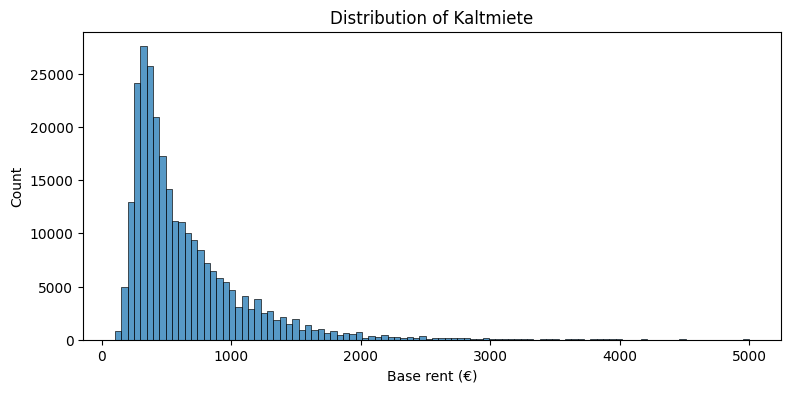

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 4))
sns.histplot(df_clean["baseRent"], bins=100)
plt.title("Distribution of Kaltmiete")
plt.xlabel("Base rent (€)")
plt.show()

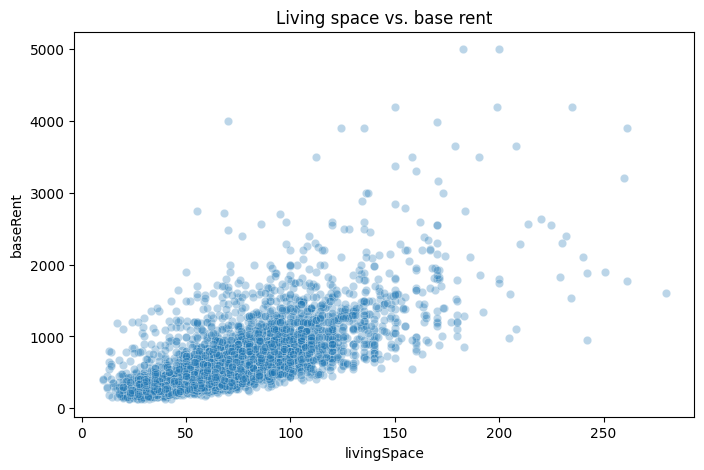

In [11]:
sample = df_clean.sample(5000, random_state=42)   # 5,000 random apartments, so the chart stays readable

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="livingSpace", y="baseRent", alpha=0.3)
plt.title("Living space vs. base rent")
plt.show()

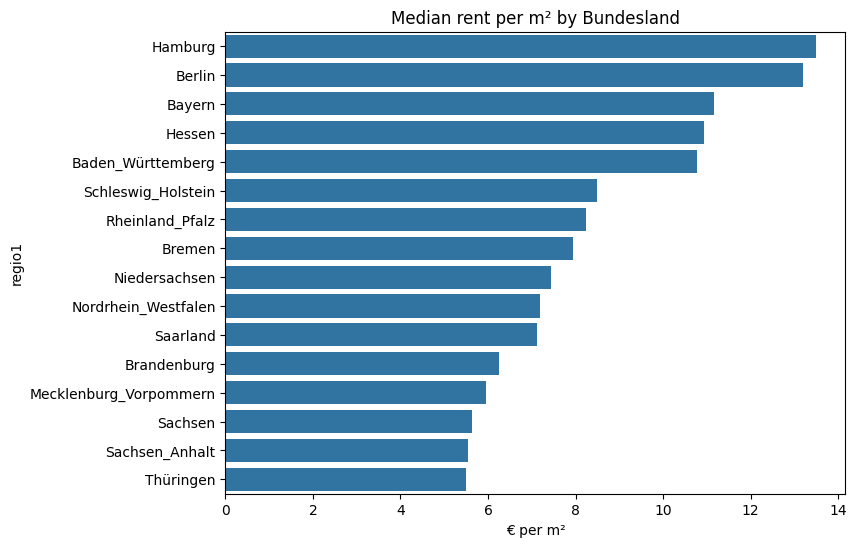

In [12]:
df_clean = df_clean.copy()
df_clean["rentPerSqm"] = df_clean["baseRent"] / df_clean["livingSpace"]

median_by_state = df_clean.groupby("regio1")["rentPerSqm"].median().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=median_by_state.values, y=median_by_state.index)
plt.title("Median rent per m² by Bundesland")
plt.xlabel("€ per m²")
plt.show()